In [1]:
train_dir = "/kaggle/input/pediatric-pneumonia-chest-xray/Pediatric Chest X-ray Pneumonia/train"
test_dir  = "/kaggle/input/pediatric-pneumonia-chest-xray/Pediatric Chest X-ray Pneumonia/test"

In [2]:
import os
from PIL import Image
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import numpy as np
from collections import Counter

from sklearn.model_selection import train_test_split
from sklearn.metrics import (roc_auc_score, accuracy_score, precision_score,
    recall_score, f1_score, confusion_matrix
)
from tqdm import tqdm


In [3]:
class PneumoDataset(Dataset):
    def __init__(self, paths, transforms=None):
        self.paths = paths
        self.transform = transforms

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        path = self.paths[idx]
        img = Image.open(path).convert("L")
        img = self.transform(img)

        # метка
        fname = os.path.basename(path).lower()
        if "bacter" in fname:
            label = 1      # бактериальная пневмония
        else:
            label = 0      # вирусная или норм

        return img, label


In [4]:
    
def gather_paths(root):
        paths = []
        for folder in os.listdir(root):
            full = os.path.join(root, folder)
            if os.path.isdir(full):
                for f in os.listdir(full):
                    if f.lower().endswith((".jpg", ".jpeg", ".png")):
                        paths.append(os.path.join(full, f))
        return paths

In [5]:
img_size = 128

train_transforms = T.Compose([
    T.RandomResizedCrop(128, scale=(0.9, 1.0)),   # новый слой
    T.ColorJitter(brightness=0.2, contrast=0.2),  # новый слой
    T.RandomHorizontalFlip(),
    T.RandomRotation(10),
    T.RandomAffine(degrees=0, translate=(0.05, 0.05)),
    T.ToTensor(),
    T.Normalize([0.5], [0.5])
])


val_transforms = T.Compose([
    T.Resize((img_size, img_size)),
    T.ToTensor(),
    T.Normalize([0.5], [0.5])
])

In [6]:
class LeNet(nn.Module):
    def __init__(self):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=5, padding=2),
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.MaxPool2d(2),  # 128 → 64

            nn.Conv2d(16, 32, kernel_size=5, padding=2),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),  # 64 → 32

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),  # 32 → 16
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 16 * 16, 256),
            nn.ReLU(),
            nn.Dropout(0.4),

            nn.Linear(256, 64),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(64, 1)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

In [7]:
!nvidia-smi


Sun Dec  7 20:56:15 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 570.172.08             Driver Version: 570.172.08     CUDA Version: 12.8     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla P100-PCIE-16GB           Off |   00000000:00:04.0 Off |                    0 |
| N/A   38C    P0             26W /  250W |       0MiB /  16384MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [8]:
all_paths = gather_paths(train_dir)
labels = [1 if "bacter" in os.path.basename(p).lower() else 0 for p in all_paths]


Баланс классов: Counter({0: 2694, 1: 2538})


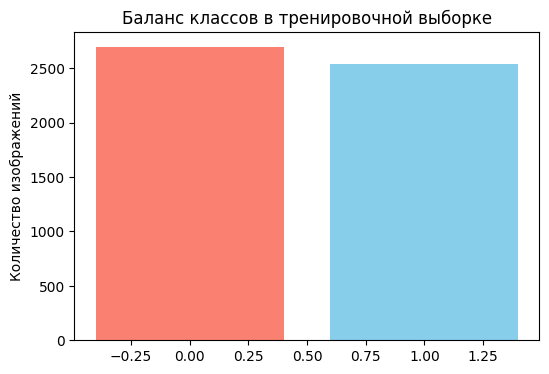

In [9]:
counter = Counter(labels)
print("Баланс классов:", counter)

# График
plt.figure(figsize=(6,4))
plt.bar(counter.keys(), counter.values(), color=["salmon", "skyblue"])
plt.title("Баланс классов в тренировочной выборке")
plt.ylabel("Количество изображений")
plt.show()

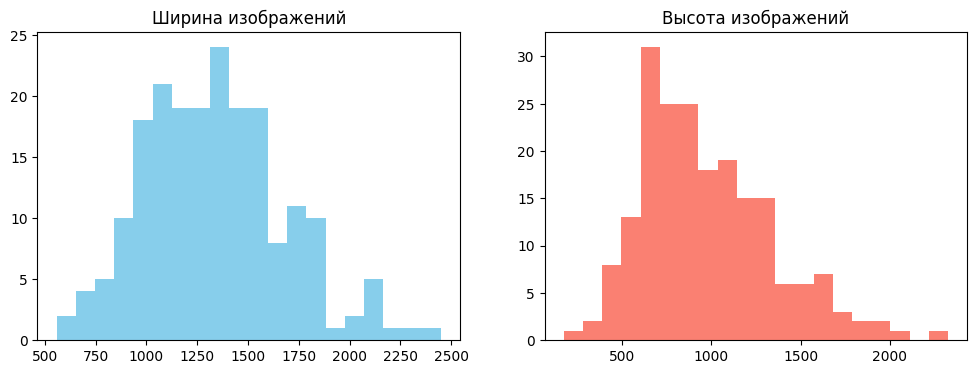

In [11]:
import random 
widths, heights = [], []
for path in random.sample(all_paths, 200):  # смотрим случайные 200 изображений
    img = Image.open(path)
    w, h = img.size
    widths.append(w)
    heights.append(h)

plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.hist(widths, bins=20, color="skyblue")
plt.title("Ширина изображений")

plt.subplot(1,2,2)
plt.hist(heights, bins=20, color="salmon")
plt.title("Высота изображений")
plt.show()

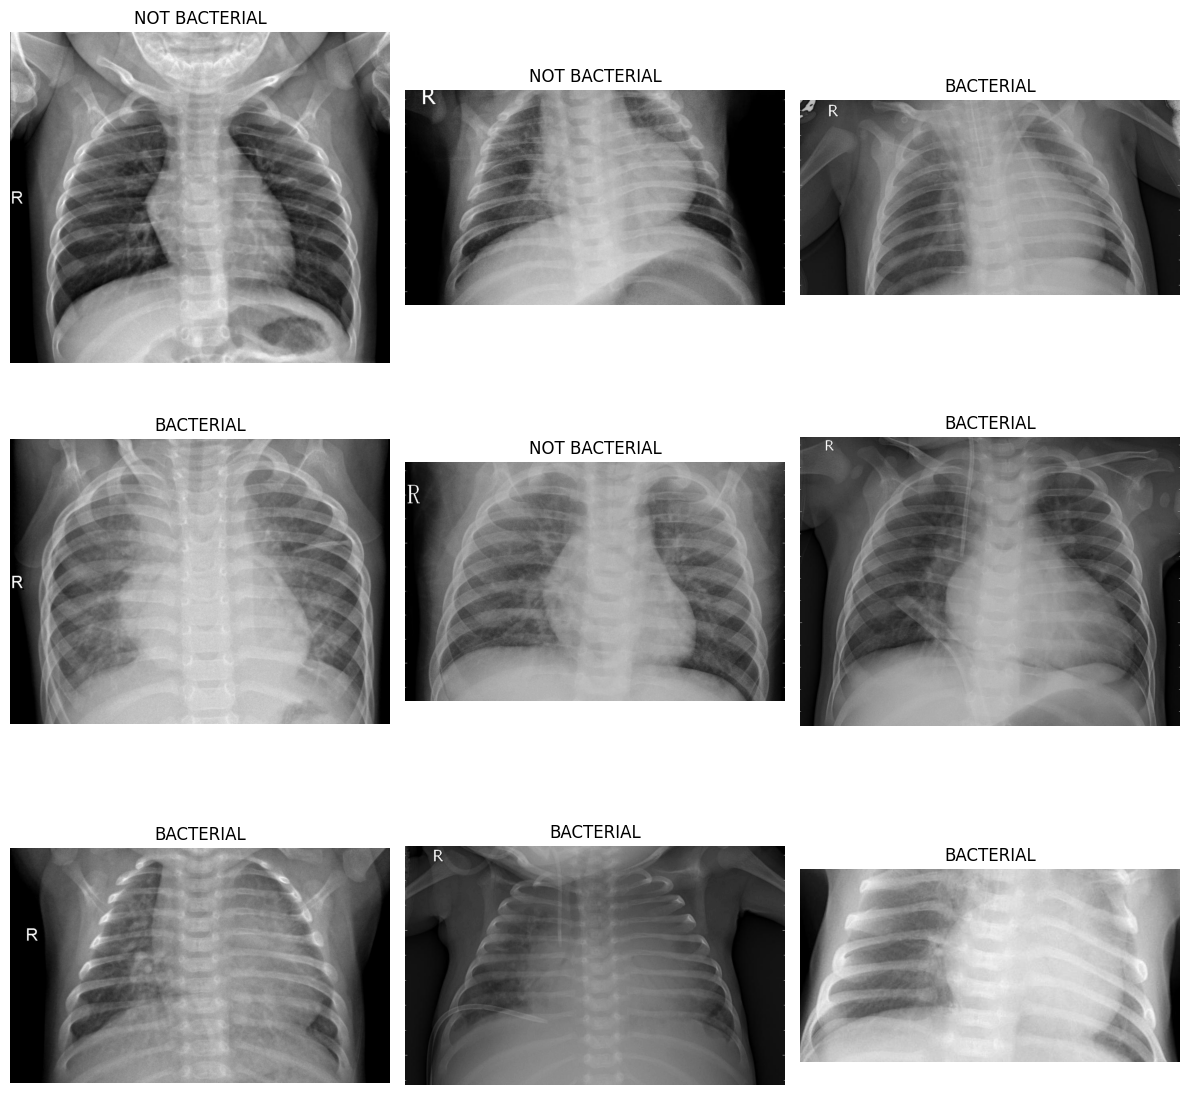

In [12]:
def show_random_images(paths, n=9):
    plt.figure(figsize=(12,12))
    for i, path in enumerate(random.sample(paths, n)):
        img = Image.open(path).convert("L")
        label = "BACTERIAL" if "bacter" in os.path.basename(path).lower() else "NOT BACTERIAL"

        plt.subplot(3,3,i+1)
        plt.imshow(img, cmap="gray")
        plt.axis("off")
        plt.title(label)
    plt.tight_layout()
    plt.show()

show_random_images(all_paths)


In [13]:

train_paths, val_paths = train_test_split(
    all_paths, test_size=0.15, stratify=labels, random_state=42
)

train_ds = PneumoDataset(train_paths, transforms=train_transforms)
val_ds = PneumoDataset(val_paths, transforms=val_transforms)

train_loader = DataLoader(train_ds, batch_size=16, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=16, shuffle=False)

In [14]:
device = "cuda" if torch.cuda.is_available() else "cpu"

model = LeNet().to(device)

pos_weight = torch.tensor([
    labels.count(0) / labels.count(1)
], device=device)

criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
opt = torch.optim.Adam(model.parameters(), lr=0.001)

In [15]:
def validate(model, loader):
    model.eval()
    preds, probs, gts = [], [], []

    with torch.no_grad():
        for x, y in loader:
            x = x.to(device)
            y = y.numpy().tolist()

            logit = model(x).squeeze(1).cpu().numpy()
            p = 1 / (1 + np.exp(-logit))

            preds += (p > 0.5).astype(int).tolist()
            probs += p.tolist()
            gts += y

    return {
        "acc": accuracy_score(gts, preds),
        "prec": precision_score(gts, preds, zero_division=0),
        "rec": recall_score(gts, preds, zero_division=0),
        "f1": f1_score(gts, preds, zero_division=0),
        "auc": roc_auc_score(gts, probs),
        "cm": confusion_matrix(gts, preds)
    }


best_auc = 0

for epoch in range(1, 41):
    model.train()
    losses = []

    for x, y in tqdm(train_loader, leave=False):
        x, y = x.to(device), y.float().to(device)

        logits = model(x).squeeze(1)
        loss = criterion(logits, y)

        opt.zero_grad()
        loss.backward()
        opt.step()

        losses.append(loss.item())

    val_stats = validate(model, val_loader)
    

    print(f"Epoch {epoch}/30")
    print(f"Train loss: {np.mean(losses):.4f}")
    print(val_stats)
    print("-" * 40)
    

    if val_stats["auc"] > best_auc:
        best_auc = val_stats["auc"]
        torch.save(model.state_dict(), "best_model.pth")
        print("new best model")

Epoch 1/30
Train loss: 0.6770
{'acc': 0.7821656050955414, 'prec': 0.7323008849557522, 'rec': 0.868766404199475, 'f1': 0.7947178871548619, 'auc': 0.8498934539123204, 'cm': array([[283, 121],
       [ 50, 331]])}
----------------------------------------
new best model


Epoch 2/30
Train loss: 0.5517
{'acc': 0.7847133757961784, 'prec': 0.8011363636363636, 'rec': 0.7401574803149606, 'f1': 0.7694406548431105, 'auc': 0.8556885216080663, 'cm': array([[334,  70],
       [ 99, 282]])}
----------------------------------------
new best model


Epoch 3/30
Train loss: 0.5375
{'acc': 0.759235668789809, 'prec': 0.6764705882352942, 'rec': 0.9658792650918635, 'f1': 0.7956756756756757, 'auc': 0.8544021725007147, 'cm': array([[228, 176],
       [ 13, 368]])}
----------------------------------------


Epoch 4/30
Train loss: 0.5275
{'acc': 0.7719745222929937, 'prec': 0.6927480916030534, 'rec': 0.952755905511811, 'f1': 0.8022099447513812, 'auc': 0.857306203061251, 'cm': array([[243, 161],
       [ 18, 363]])}
----------------------------------------
new best model


Epoch 5/30
Train loss: 0.5265
{'acc': 0.780891719745223, 'prec': 0.7128309572301426, 'rec': 0.9186351706036745, 'f1': 0.8027522935779817, 'auc': 0.8714755333801097, 'cm': array([[263, 141],
       [ 31, 350]])}
----------------------------------------
new best model


...

Epoch 36/30
Train loss: 0.4219
{'acc': 0.8356687898089172, 'prec': 0.7876712328767124, 'rec': 0.905511811023622, 'f1': 0.8424908424908425, 'auc': 0.9073763675580157, 'cm': array([[311,  93],
       [ 36, 345]])}
----------------------------------------


Epoch 37/30
Train loss: 0.4270
{'acc': 0.8445859872611465, 'prec': 0.8090692124105012, 'rec': 0.889763779527559, 'f1': 0.8475, 'auc': 0.9095722564382421, 'cm': array([[324,  80],
       [ 42, 339]])}
----------------------------------------
new best model


Epoch 38/30
Train loss: 0.4169
{'acc': 0.8394904458598726, 'prec': 0.7917620137299771, 'rec': 0.9081364829396326, 'f1': 0.8459657701711493, 'auc': 0.9088316311946155, 'cm': array([[313,  91],
       [ 35, 346]])}
----------------------------------------


Epoch 39/30
Train loss: 0.4143
{'acc': 0.845859872611465, 'prec': 0.7914798206278026, 'rec': 0.926509186351706, 'f1': 0.8536880290205561, 'auc': 0.9125217639874224, 'cm': array([[311,  93],
       [ 28, 353]])}
----------------------------------------
new best model


Epoch 40/30
Train loss: 0.4074
{'acc': 0.8420382165605096, 'prec': 0.7874720357941835, 'rec': 0.9238845144356955, 'f1': 0.8502415458937198, 'auc': 0.903770692029833, 'cm': array([[309,  95],
       [ 29, 352]])}
----------------------------------------


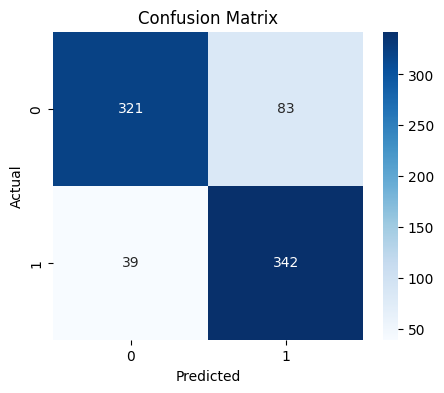

In [18]:
import seaborn as sns

cm = np.array([[321,  83],
               [ 39, 342]])  # пример твоего последнего результата

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()


In [23]:

test_paths = gather_paths(test_dir)

# создаём Dataset
test_ds = PneumoDataset(test_paths, transforms=val_transforms)

# DataLoader
test_loader = DataLoader(test_ds, batch_size=16, shuffle=False)

In [24]:
def test_model(model, loader, criterion):
    model.eval()
    all_preds = []
    all_probs = []
    all_labels = []
    total_loss = 0
    n_samples = 0

    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.float().to(device)
            logits = model(x).squeeze(1)

            # loss
            loss = criterion(logits, y)
            total_loss += loss.item() * x.size(0)
            n_samples += x.size(0)

            # предсказания
            probs = torch.sigmoid(logits).cpu().numpy()
            preds = (probs > 0.5).astype(int)

            all_preds.extend(preds)
            all_probs.extend(probs)
            all_labels.extend(y.cpu().numpy())

    # усреднённый loss
    test_loss = total_loss / n_samples

    # метрики
    metrics = {
        "test_loss": test_loss,
        "acc": accuracy_score(all_labels, all_preds),
        "prec": precision_score(all_labels, all_preds, zero_division=0),
        "rec": recall_score(all_labels, all_preds, zero_division=0),
        "f1": f1_score(all_labels, all_preds, zero_division=0),
        "auc": roc_auc_score(all_labels, all_probs),
        "cm": confusion_matrix(all_labels, all_preds)
    }

    return metrics



test_stats = test_model(model, test_loader, criterion)
print("=== Test set metrics ===")
print(test_stats)


=== Test set metrics ===
{'test_loss': 0.36046061645715666, 'acc': 0.8669871794871795, 'prec': 0.7556270096463023, 'rec': 0.9710743801652892, 'f1': 0.8499095840867993, 'auc': 0.9581368179654712, 'cm': array([[306,  76],
       [  7, 235]])}


## Уменьшить ошибку 

In [19]:
import random
import math

def predict_random_grid(test_dir, batch_size=9, cols=3):
    # собрать все картинки
    all_paths = []
    for folder in os.listdir(test_dir):
        full = os.path.join(test_dir, folder)
        if os.path.isdir(full):
            for f in os.listdir(full):
                if f.lower().endswith((".jpg", ".jpeg", ".png")):
                    all_paths.append(os.path.join(full, f))

    # выбираем случайные изображения
    paths = random.sample(all_paths, batch_size)

    # подготовка изображений
    imgs = []
    true_labels = []

    for path in paths:
        img = Image.open(path).convert("L")
        imgs.append(val_transforms(img))

        fname = os.path.basename(path).lower()
        label = 1 if "bacter" in fname else 0
        true_labels.append(label)

    batch = torch.stack(imgs).to(device)

    # предсказание
    model.eval()
    with torch.no_grad():
        logits = model(batch).squeeze(1)
        probs = torch.sigmoid(logits).cpu().numpy()

    preds = (probs > 0.5).astype(int)

    # GRID
    rows = math.ceil(batch_size / cols)
    plt.figure(figsize=(4 * cols, 4 * rows))

    for i, path in enumerate(paths):
        img = Image.open(path).convert("L")

        plt.subplot(rows, cols, i + 1)
        plt.imshow(img, cmap="gray")
        plt.axis("off")

        pred_label = "BACTERIAL" if preds[i] else "NOT BACTERIAL"
        real_label = "BACTERIAL" if true_labels[i] else "NOT BACTERIAL"

        color = "green" if preds[i] == true_labels[i] else "red"

        plt.title(
            f"PRED: {pred_label}\nREAL: {real_label}\nProb={probs[i]:.2f}",
            color=color,
            fontsize=10
        )

    plt.tight_layout()
    plt.show()

    return paths, preds, probs


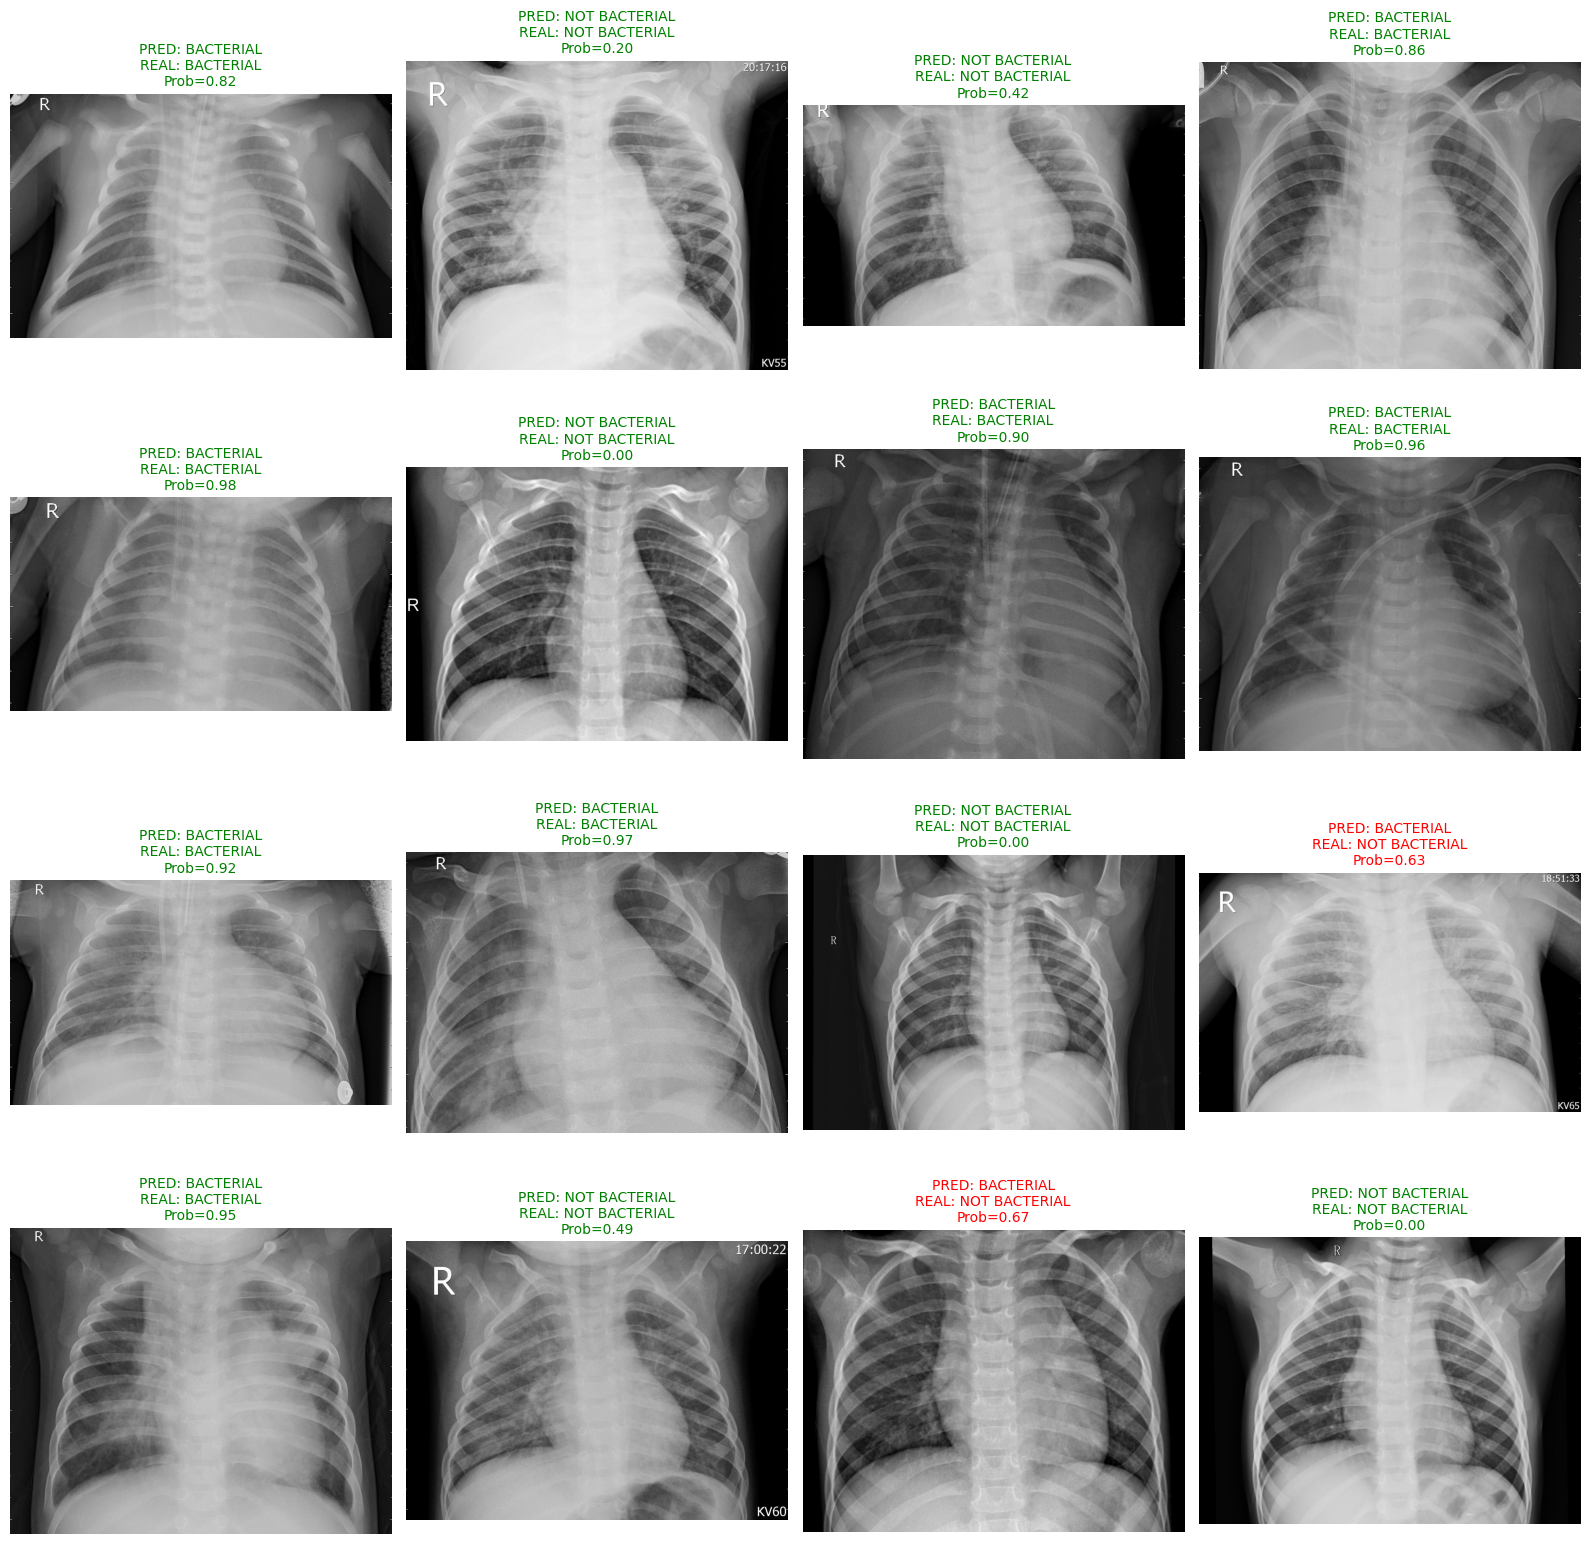

(['/kaggle/input/pediatric-pneumonia-chest-xray/Pediatric Chest X-ray Pneumonia/test/PNEUMONIA/person81_bacteria_395.jpeg',
  '/kaggle/input/pediatric-pneumonia-chest-xray/Pediatric Chest X-ray Pneumonia/test/PNEUMONIA/person38_virus_83.jpeg',
  '/kaggle/input/pediatric-pneumonia-chest-xray/Pediatric Chest X-ray Pneumonia/test/PNEUMONIA/person1662_virus_2875.jpeg',
  '/kaggle/input/pediatric-pneumonia-chest-xray/Pediatric Chest X-ray Pneumonia/test/PNEUMONIA/person99_bacteria_473.jpeg',
  '/kaggle/input/pediatric-pneumonia-chest-xray/Pediatric Chest X-ray Pneumonia/test/PNEUMONIA/person78_bacteria_386.jpeg',
  '/kaggle/input/pediatric-pneumonia-chest-xray/Pediatric Chest X-ray Pneumonia/test/NORMAL/NORMAL2-IM-0286-0001.jpeg',
  '/kaggle/input/pediatric-pneumonia-chest-xray/Pediatric Chest X-ray Pneumonia/test/PNEUMONIA/person161_bacteria_757.jpeg',
  '/kaggle/input/pediatric-pneumonia-chest-xray/Pediatric Chest X-ray Pneumonia/test/PNEUMONIA/person122_bacteria_584.jpeg',
  '/kaggle/inp

In [20]:

predict_random_grid(test_dir, batch_size=16, cols=4)
